Dataset Shape: (1025, 14)

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Basic Statistics:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.

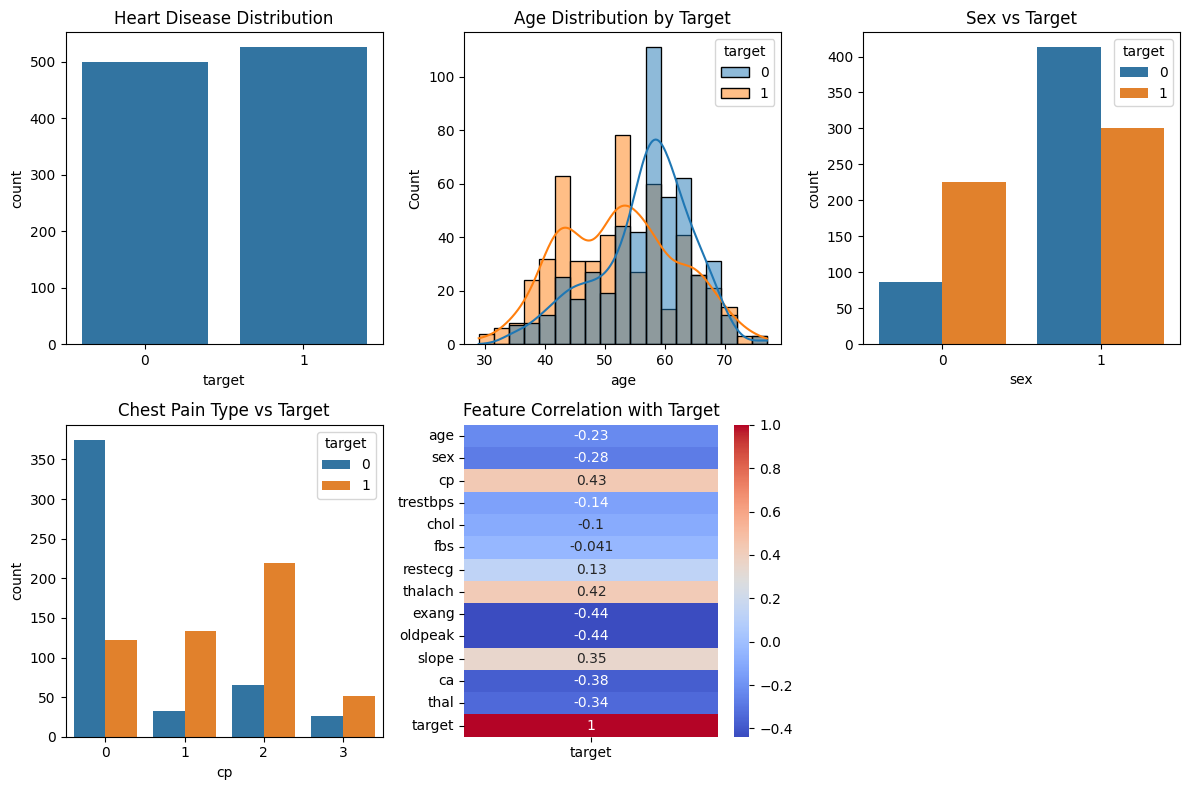

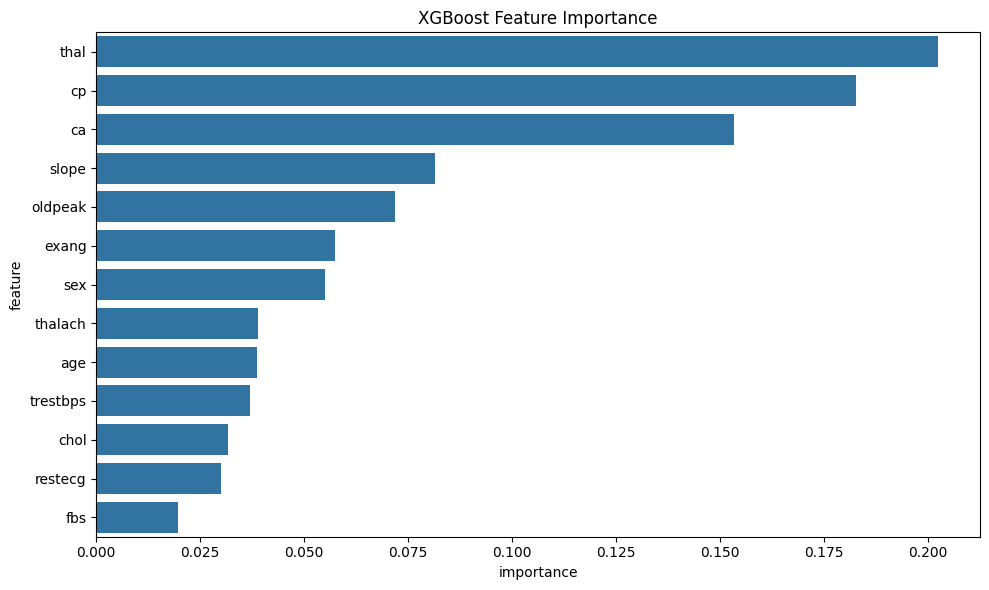

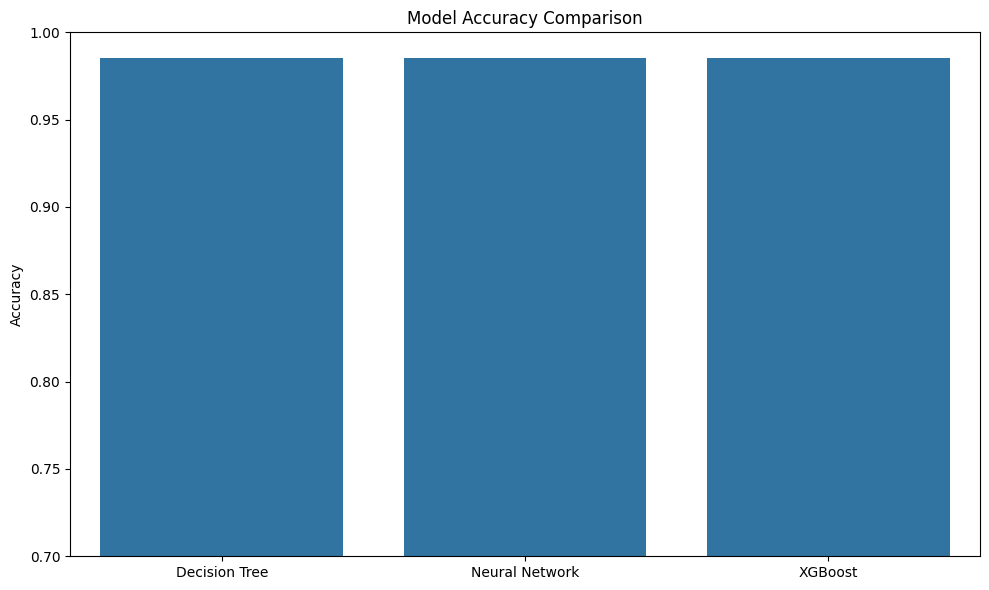

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('heart.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Exploratory Data Analysis
plt.figure(figsize=(12, 8))

# Distribution of target variable
plt.subplot(2, 3, 1)
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')

# Age distribution by target
plt.subplot(2, 3, 2)
sns.histplot(data=df, x='age', hue='target', kde=True)
plt.title('Age Distribution by Target')

# Sex distribution by target
plt.subplot(2, 3, 3)
sns.countplot(x='sex', hue='target', data=df)
plt.title('Sex vs Target')

# Chest pain type by target
plt.subplot(2, 3, 4)
sns.countplot(x='cp', hue='target', data=df)
plt.title('Chest Pain Type vs Target')

# Correlation matrix
plt.subplot(2, 3, 5)
correlation = df.corr()
sns.heatmap(correlation['target'].to_frame(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Target')

plt.tight_layout()
plt.savefig('heart_eda.png')

# Data preparation
X = df.iloc[:, :13].values
y = df.iloc[:, 13].values

# Split the data with a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Decision Tree model with cross-validation
def evaluate_decision_tree():
    print("\n--- Decision Tree Model Evaluation ---")
    # Define parameter grid
    param_grid = {
        'criterion': ['gini', 'entropy'],
        'max_depth': [4, 6, 8, 10],
        'min_samples_split': [2, 3, 5],
        'max_features': [None, 'sqrt', 'log2']
    }
    
    # Grid search
    grid_search = GridSearchCV(
        DecisionTreeClassifier(random_state=42), 
        param_grid, 
        cv=5, 
        scoring='accuracy',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    # Best parameters and model
    print("Best Parameters:", grid_search.best_params_)
    best_tree = grid_search.best_estimator_
    
    # Cross-validation score
    cv_scores = cross_val_score(best_tree, X_train, y_train, cv=10)
    print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # Evaluation on test set
    y_pred = best_tree.predict(X_test)
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return best_tree

# Neural Network model
def evaluate_neural_network():
    print("\n--- Neural Network Model Evaluation ---")
    # Use scaled features for neural network
    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size='auto',
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    )
    
    mlp.fit(X_train_scaled, y_train)
    
    # Evaluation on test set
    y_pred = mlp.predict(X_test_scaled)
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return mlp

# XGBoost model
def evaluate_xgboost():
    print("\n--- XGBoost Model Evaluation ---")
    
    # For multi:softprob objective, we need to set num_class
    # Here we're doing binary classification, so we should use binary:logistic instead
    xgb_model = XGBClassifier(
        objective='binary:logistic',  # Changed from 'multi:softprob'
        learning_rate=0.1,
        n_estimators=100,
        max_depth=5,
        min_child_weight=1,
        gamma=0,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    # Hyperparameter tuning
    param_grid = {
        'learning_rate': [0.05, 0.1, 0.3],
        'max_depth': [3, 5, 7],
        'n_estimators': [50, 100, 200]
    }
    
    grid_search = GridSearchCV(
        xgb_model,
        param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Best parameters and model
    print("Best Parameters:", grid_search.best_params_)
    best_xgb = grid_search.best_estimator_
    
    # Evaluation on test set
    y_pred = best_xgb.predict(X_test)
    predictions = [round(value) for value in y_pred]
    print(f"Test Accuracy: {accuracy_score(y_test, predictions):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))
    
    # Feature importance
    plt.figure(figsize=(10, 6))
    feature_importance = pd.DataFrame({
        'feature': df.columns[:13],
        'importance': best_xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    sns.barplot(x='importance', y='feature', data=feature_importance)
    plt.title('XGBoost Feature Importance')
    plt.tight_layout()
    plt.savefig('xgboost_feature_importance.png')
    
    return best_xgb

# Model comparison
def compare_models(models_dict):
    print("\n--- Model Comparison ---")
    results = {}
    
    for name, model in models_dict.items():
        if name == 'Neural Network':
            y_pred = model.predict(X_test_scaled)
        else:
            y_pred = model.predict(X_test)
            
        if name == 'XGBoost':
            y_pred = [round(value) for value in y_pred]
            
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = accuracy
        
    # Display results
    for name, accuracy in results.items():
        print(f"{name} Accuracy: {accuracy:.4f}")
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(results.keys()), y=list(results.values()))
    plt.ylim(0.7, 1.0)
    plt.title('Model Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.tight_layout()
    plt.savefig('model_comparison.png')

# Run the evaluation
if __name__ == "__main__":
    # Run all models
    decision_tree = evaluate_decision_tree()
    neural_network = evaluate_neural_network()
    xgboost = evaluate_xgboost()
    
    # Compare models
    models = {
        'Decision Tree': decision_tree,
        'Neural Network': neural_network,
        'XGBoost': xgboost
    }
    
    compare_models(models)

Dataset Shape: (1025, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Target distribution:
target
1    526
0    499
Name: count, dtype: int64
Original class distribution:
Counter({1: 526, 0: 499})
Class distribution after SMOTE:
Counter({0: 526, 1: 526})
Size of X_train: (841, 13)
Size of X_test: (211, 13)

--- SVM Model Evaluation ---

Training SVM with linear kernel...
Accuracy with linear kernel: 0.8199

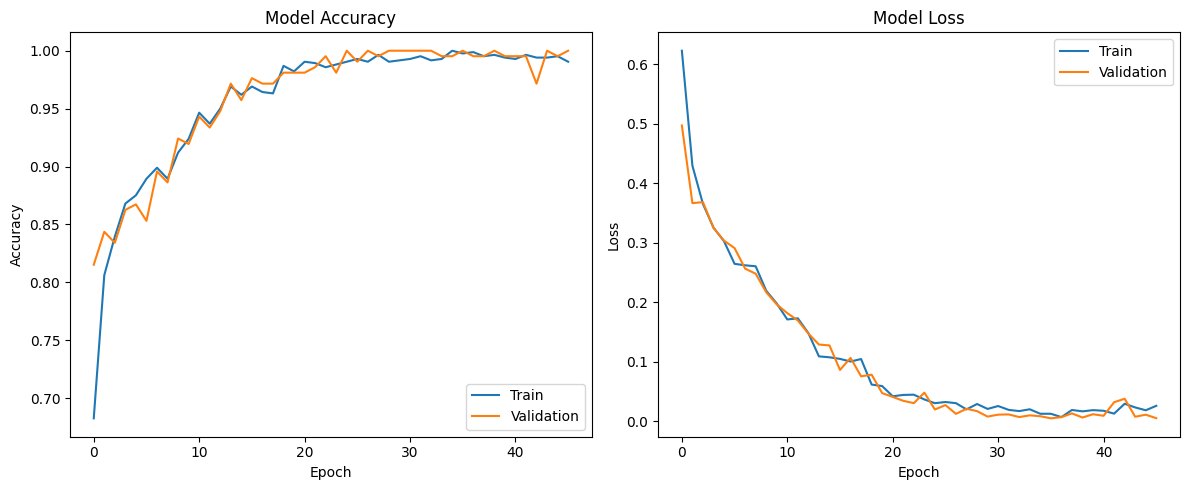

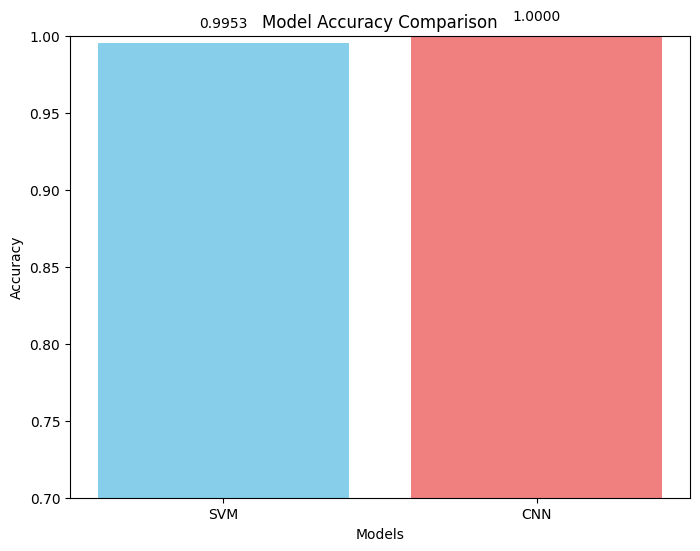

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from collections import Counter
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.layers import Flatten, Dense, Conv1D, MaxPool1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# 1. DATA PREPROCESSING
def preprocess_data(df, oversample=False, test_size=0.2):
    """
    Preprocess the heart disease dataset
    """
    # Separate features and target
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    
    print("Original class distribution:")
    counter_before = Counter(y)
    print(counter_before)
    
    # Apply SMOTE oversampling if requested
    if oversample:
        oversample = SMOTE(random_state=42)
        X, y = oversample.fit_resample(X, y)
        print("Class distribution after SMOTE:")
        counter_after = Counter(y)
        print(counter_after)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print('Size of X_train:', X_train.shape)
    print('Size of X_test:', X_test.shape)
    
    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test

# 2. SVM MODELS
def evaluate_svm_models(X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Train and evaluate SVM models with different kernels
    """
    print("\n--- SVM Model Evaluation ---")
    
    # Define kernels to test
    kernels = ['linear', 'poly', 'rbf', 'sigmoid']
    
    # Train and evaluate SVM with different kernels
    results = {}
    best_accuracy = 0
    best_svm = None
    
    for kernel in kernels:
        print(f"\nTraining SVM with {kernel} kernel...")
        
        # Create and train SVM classifier
        svm = SVC(kernel=kernel, random_state=42, probability=True)
        svm.fit(X_train_scaled, y_train)
        
        # Predictions
        y_pred = svm.predict(X_test_scaled)
        
        # Evaluation
        accuracy = accuracy_score(y_test, y_pred)
        results[kernel] = accuracy
        
        print(f"Accuracy with {kernel} kernel: {accuracy:.4f}")
        print("Confusion Matrix:")
        cm = confusion_matrix(y_test, y_pred)
        print(cm)
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        
        # Keep track of the best model
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_svm = svm
    
    # Hyperparameter tuning for the best kernel
    best_kernel = max(results, key=results.get)
    print(f"\nPerforming hyperparameter tuning for SVM with {best_kernel} kernel...")
    
    # Define parameter grid
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
    }
    
    # Grid search with cross-validation
    grid_search = GridSearchCV(
        SVC(kernel=best_kernel, probability=True, random_state=42),
        param_grid, 
        cv=5, 
        scoring='accuracy', 
        n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train)
    
    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)
    
    # Evaluate best model
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    
    print("Final model accuracy:", accuracy_score(y_test, y_pred))
    print("Final confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Final classification report:")
    print(classification_report(y_test, y_pred))
    
    return best_model

# 3. CNN MODEL
def build_and_train_cnn(X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Build and train a 1D CNN model for heart disease classification
    """
    print("\n--- CNN Model Evaluation ---")
    
    # Reshape input data for CNN
    X_train_cnn = np.array(X_train_scaled).reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
    X_test_cnn = np.array(X_test_scaled).reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
    
    print("X Train CNN shape:", X_train_cnn.shape)
    print("X Test CNN shape:", X_test_cnn.shape)
    
    # Check unique classes in target
    unique_classes = len(np.unique(y_train))
    print(f"Number of unique classes: {unique_classes}")
    
    # Define CNN model
    cnn_model = tf.keras.models.Sequential([
        # Convolutional layers
        Conv1D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
        Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
        MaxPool1D(pool_size=2),
        
        # Second conv block
        Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
        MaxPool1D(pool_size=2),
        Dropout(0.3),
        
        # Flatten and dense layers
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        # For binary classification, use 1 unit with sigmoid activation
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model with appropriate loss function
    cnn_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',  # Binary classification
        metrics=['accuracy']
    )
    
    # Model summary
    cnn_model.summary()
    
    # Early stopping to prevent overfitting
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train model
    history = cnn_model.fit(
        X_train_cnn, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test_cnn, y_test),
        callbacks=[early_stop]
    )
    
    # Plot training history
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.savefig('cnn_training_history.png')
    
    # Evaluate model
    loss, accuracy = cnn_model.evaluate(X_test_cnn, y_test)
    print(f"CNN Test accuracy: {accuracy:.4f}")
    
    # Get predictions
    y_pred_probs = cnn_model.predict(X_test_cnn)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    
    print("CNN Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("CNN Classification Report:")
    print(classification_report(y_test, y_pred))
    
    return cnn_model, history

# 4. MODEL COMPARISON
def compare_models(svm_model, cnn_model, X_test_scaled, y_test):
    """
    Compare SVM and CNN model performance
    """
    print("\n--- Model Comparison ---")
    
    # Reshape for CNN
    X_test_cnn = np.array(X_test_scaled).reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
    
    # Get predictions from SVM
    y_pred_svm = svm_model.predict(X_test_scaled)
    svm_accuracy = accuracy_score(y_test, y_pred_svm)
    
    # Get predictions from CNN
    y_pred_probs_cnn = cnn_model.predict(X_test_cnn)
    y_pred_cnn = (y_pred_probs_cnn > 0.5).astype(int).flatten()
    cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
    
    # Compare results
    print(f"SVM Accuracy: {svm_accuracy:.4f}")
    print(f"CNN Accuracy: {cnn_accuracy:.4f}")
    
    # Plot comparison
    models = ['SVM', 'CNN']
    accuracies = [svm_accuracy, cnn_accuracy]
    
    plt.figure(figsize=(8, 6))
    plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])
    plt.ylim(0.7, 1.0)
    plt.title('Model Accuracy Comparison')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    
    # Add accuracy values on top of bars
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
    
    plt.savefig('model_comparison.png')
    
    # Return the best model name
    if cnn_accuracy > svm_accuracy:
        print("\nCNN model performs better.")
        return "CNN"
    else:
        print("\nSVM model performs better.")
        return "SVM"

# 5. MAIN EXECUTION
def main():
    """
    Main function to execute the heart disease classification pipeline
    """
    # Load the dataset
    df = pd.read_csv('heart.csv')
    
    # Display basic info
    print("Dataset Shape:", df.shape)
    print("\nFirst 5 rows:")
    print(df.head())
    
    # Check class distribution
    print("\nTarget distribution:")
    print(df['target'].value_counts())
    
    # Preprocess data
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = preprocess_data(df, oversample=True)
    
    # Train and evaluate SVM models
    best_svm = evaluate_svm_models(X_train_scaled, X_test_scaled, y_train, y_test)
    
    # Train and evaluate CNN model
    cnn_model, history = build_and_train_cnn(X_train_scaled, X_test_scaled, y_train, y_test)
    
    # Compare models
    best_model_name = compare_models(best_svm, cnn_model, X_test_scaled, y_test)
    
    print(f"\nBest model is {best_model_name}")

# Run the main function
if __name__ == "__main__":
    main()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from collections import Counter
from imblearn.over_sampling import SMOTE
import os
import warnings
warnings.filterwarnings('ignore')

# Create directory to save models
os.makedirs('models', exist_ok=True)

print("Starting model training and saving process...")

# Load the dataset
print("Loading dataset...")
df = pd.read_csv('heart.csv')
print(f"Dataset shape: {df.shape}")

# Display basic information
print("\nFirst 5 rows:")
print(df.head())

print("\nTarget distribution:")
print(df['target'].value_counts())

# Data preparation
X = df.iloc[:, :13].values
y = df.iloc[:, 13].values

print("\nApplying SMOTE for balanced classes...")
# Apply SMOTE for balancing classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("Class distribution after SMOTE:", Counter(y_resampled))

# Split the data
print("\nSplitting data into train/test sets...")
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

# Feature scaling
print("\nApplying feature scaling...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler
print("\nSaving the scaler...")
joblib.dump(scaler, 'models/scaler.pkl')
print("✓ Scaler saved successfully.")

# Save column names for the web application
print("\nSaving column names...")
with open('models/column_names.pkl', 'wb') as f:
    pickle.dump(df.columns[:-1].tolist(), f)
print("✓ Column names saved successfully.")

# 1. Train and save Decision Tree model
print("\n1. Training Decision Tree model...")
best_tree = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=10, 
    max_features=None, 
    min_samples_split=2,
    random_state=42
)
best_tree.fit(X_train, y_train)
y_pred = best_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Save the model
print("Saving Decision Tree model...")
joblib.dump(best_tree, 'models/decision_tree_model.pkl')
print("✓ Decision Tree model saved successfully.")

# 2. Train and save Neural Network model
print("\n2. Training Neural Network model...")
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Neural Network accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Save the model
print("Saving Neural Network model...")
joblib.dump(mlp, 'models/neural_network_model.pkl')
print("✓ Neural Network model saved successfully.")

# 3. Train and save SVM model
print("\n3. Training SVM model...")
svm = SVC(
    kernel='poly',
    C=100,
    gamma='scale',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Save the model
print("Saving SVM model...")
joblib.dump(svm, 'models/svm_model.pkl')
print("✓ SVM model saved successfully.")

# 4. Train and save XGBoost model
print("\n4. Training XGBoost model...")
xgb = XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.1,
    max_depth=7,
    n_estimators=200,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Save the model
print("Saving XGBoost model...")
joblib.dump(xgb, 'models/xgboost_model.pkl')
print("✓ XGBoost model saved successfully.")

# 5. Train and save CNN model
print("\n5. Training CNN model...")
# Reshape input data for CNN
X_train_cnn = np.array(X_train_scaled).reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = np.array(X_test_scaled).reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Define CNN model
print("Building CNN architecture...")
cnn_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
    tf.keras.layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN model summary:")
cnn_model.summary()

# Early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train model
print("\nTraining CNN model...")
history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=30,  # Reduced from 50 for faster training
    batch_size=32,
    validation_data=(X_test_cnn, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Evaluate model
print("\nEvaluating CNN model...")
loss, accuracy = cnn_model.evaluate(X_test_cnn, y_test)
print(f"CNN test accuracy: {accuracy:.4f}")

# Predictions
y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Save the model
print("Saving CNN model...")
cnn_model.save('models/cnn_model')
print("✓ CNN model saved successfully.")

print("\n✓ All models have been saved successfully!")
print("You can now run the Flask application to make predictions.")

Starting model training and saving process...
Loading dataset...
Dataset shape: (1025, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Target distribution:
target
1    526
0    499
Name: count, dtype: int64

Applying SMOTE for balanced classes...
Class distribution after SMOTE: Counter({0: 526, 1: 526})

Splitting data into train/test sets...
Training set size: 841, Test set size: 211

Applying feature sca

INFO:tensorflow:Assets written to: models/cnn_model\assets


INFO:tensorflow:Assets written to: models/cnn_model\assets


✓ CNN model saved successfully.

✓ All models have been saved successfully!
You can now run the Flask application to make predictions.


In [3]:
from flask import Flask, request, jsonify
import numpy as np
import pandas as pd
import pickle
import joblib
import os
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

app = Flask(__name__)

# Define global variables for models
scaler = None
column_names = None
decision_tree = None
neural_network = None
svm = None
xgboost = None
cnn_model = None

# Load models function
def load_models():
    global scaler, column_names, decision_tree, neural_network, svm, xgboost, cnn_model
    
    print("Loading models...")
    
    # Load scaler
    scaler = joblib.load('models/scaler.pkl')
    
    # Load column names
    with open('models/column_names.pkl', 'rb') as f:
        column_names = pickle.load(f)
    
    # Load ML models
    decision_tree = joblib.load('models/decision_tree_model.pkl')
    neural_network = joblib.load('models/neural_network_model.pkl')
    svm = joblib.load('models/svm_model.pkl')
    xgboost = joblib.load('models/xgboost_model.pkl')
    
    # Load CNN model
    cnn_model = tf.keras.models.load_model('models/cnn_model')
    
    print("✓ All models loaded successfully!")

# Create a before_request handler to ensure models are loaded
@app.before_request
def before_request():
    if scaler is None:
        load_models()

# Route for home page
@app.route('/', methods=['GET'])
def home():
    return jsonify({
        'message': 'Heart Disease Prediction API',
        'endpoints': {
            '/predict': 'POST request to predict heart disease with all models',
            '/predict/decision_tree': 'POST request to predict using Decision Tree',
            '/predict/neural_network': 'POST request to predict using Neural Network',
            '/predict/svm': 'POST request to predict using SVM',
            '/predict/xgboost': 'POST request to predict using XGBoost',
            '/predict/cnn': 'POST request to predict using CNN'
        },
        'example_payload': {
            'age': 52,
            'sex': 1,
            'cp': 0,
            'trestbps': 125,
            'chol': 212,
            'fbs': 0,
            'restecg': 1,
            'thalach': 168,
            'exang': 0,
            'oldpeak': 1.0,
            'slope': 2,
            'ca': 2,
            'thal': 3
        }
    })

# Helper function to preprocess input data
def preprocess_input(data):
    # Convert input data to dataframe
    input_df = pd.DataFrame([data])
    
    # Check if all required features are present
    missing_cols = set(column_names) - set(input_df.columns)
    if missing_cols:
        return None, f"Missing required features: {', '.join(missing_cols)}"
    
    # Ensure correct order of features
    input_df = input_df[column_names]
    
    # Convert to numpy array
    input_array = input_df.values
    
    # Scale the input data
    input_scaled = scaler.transform(input_array)
    
    # Prepare input for CNN
    input_cnn = np.array(input_scaled).reshape(input_scaled.shape[0], input_scaled.shape[1], 1)
    
    return {
        'raw': input_array,
        'scaled': input_scaled,
        'cnn': input_cnn
    }, None

# Route for predicting with all models
@app.route('/predict', methods=['POST'])
def predict_all():
    try:
        # Get input data from request
        data = request.json
        
        # Preprocess input data
        inputs, error = preprocess_input(data)
        if error:
            return jsonify({'error': error}), 400
        
        # Make predictions with all models
        dt_pred = int(decision_tree.predict(inputs['raw'])[0])
        nn_pred = int(neural_network.predict(inputs['scaled'])[0])
        svm_pred = int(svm.predict(inputs['scaled'])[0])
        xgb_pred = int(xgboost.predict(inputs['raw'])[0])
        cnn_pred = int((cnn_model.predict(inputs['cnn']) > 0.5)[0][0])
        
        # Calculate ensemble prediction (majority vote)
        predictions = [dt_pred, nn_pred, svm_pred, xgb_pred, cnn_pred]
        ensemble_pred = int(np.bincount(predictions).argmax())
        
        # Get prediction probabilities where available
        nn_prob = float(neural_network.predict_proba(inputs['scaled'])[0][1])
        svm_prob = float(svm.predict_proba(inputs['scaled'])[0][1])
        xgb_prob = float(xgboost.predict_proba(inputs['raw'])[0][1])
        cnn_prob = float(cnn_model.predict(inputs['cnn'])[0][0])
        
        # Return results
        return jsonify({
            'predictions': {
                'decision_tree': {
                    'class': dt_pred,
                    'label': 'Heart Disease' if dt_pred == 1 else 'No Heart Disease'
                },
                'neural_network': {
                    'class': nn_pred,
                    'probability': nn_prob,
                    'label': 'Heart Disease' if nn_pred == 1 else 'No Heart Disease'
                },
                'svm': {
                    'class': svm_pred,
                    'probability': svm_prob,
                    'label': 'Heart Disease' if svm_pred == 1 else 'No Heart Disease'
                },
                'xgboost': {
                    'class': xgb_pred,
                    'probability': xgb_prob,
                    'label': 'Heart Disease' if xgb_pred == 1 else 'No Heart Disease'
                },
                'cnn': {
                    'class': cnn_pred,
                    'probability': cnn_prob,
                    'label': 'Heart Disease' if cnn_pred == 1 else 'No Heart Disease'
                },
                'ensemble': {
                    'class': ensemble_pred,
                    'label': 'Heart Disease' if ensemble_pred == 1 else 'No Heart Disease'
                }
            },
            'input_data': data
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

# Individual model prediction routes
@app.route('/predict/decision_tree', methods=['POST'])
def predict_decision_tree():
    try:
        data = request.json
        inputs, error = preprocess_input(data)
        if error:
            return jsonify({'error': error}), 400
            
        prediction = int(decision_tree.predict(inputs['raw'])[0])
        return jsonify({
            'prediction': {
                'class': prediction,
                'label': 'Heart Disease' if prediction == 1 else 'No Heart Disease'
            },
            'input_data': data
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/predict/neural_network', methods=['POST'])
def predict_neural_network():
    try:
        data = request.json
        inputs, error = preprocess_input(data)
        if error:
            return jsonify({'error': error}), 400
            
        prediction = int(neural_network.predict(inputs['scaled'])[0])
        probability = float(neural_network.predict_proba(inputs['scaled'])[0][1])
        return jsonify({
            'prediction': {
                'class': prediction,
                'probability': probability,
                'label': 'Heart Disease' if prediction == 1 else 'No Heart Disease'
            },
            'input_data': data
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/predict/svm', methods=['POST'])
def predict_svm():
    try:
        data = request.json
        inputs, error = preprocess_input(data)
        if error:
            return jsonify({'error': error}), 400
            
        prediction = int(svm.predict(inputs['scaled'])[0])
        probability = float(svm.predict_proba(inputs['scaled'])[0][1])
        return jsonify({
            'prediction': {
                'class': prediction,
                'probability': probability,
                'label': 'Heart Disease' if prediction == 1 else 'No Heart Disease'
            },
            'input_data': data
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/predict/xgboost', methods=['POST'])
def predict_xgboost():
    try:
        data = request.json
        inputs, error = preprocess_input(data)
        if error:
            return jsonify({'error': error}), 400
            
        prediction = int(xgboost.predict(inputs['raw'])[0])
        probability = float(xgboost.predict_proba(inputs['raw'])[0][1])
        return jsonify({
            'prediction': {
                'class': prediction,
                'probability': probability,
                'label': 'Heart Disease' if prediction == 1 else 'No Heart Disease'
            },
            'input_data': data
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/predict/cnn', methods=['POST'])
def predict_cnn():
    try:
        data = request.json
        inputs, error = preprocess_input(data)
        if error:
            return jsonify({'error': error}), 400
            
        probability = float(cnn_model.predict(inputs['cnn'])[0][0])
        prediction = int(probability > 0.5)
        return jsonify({
            'prediction': {
                'class': prediction,
                'probability': probability,
                'label': 'Heart Disease' if prediction == 1 else 'No Heart Disease'
            },
            'input_data': data
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

# Run the app
if __name__ == '__main__':
    # Load models at startup
    print("Initializing models at startup...")
    load_models()
    
    # Run in debug mode
    app.run(debug=False, host='0.0.0.0', port=5000)

ModuleNotFoundError: No module named 'flask'

In [2]:
from flask import Flask, request, jsonify, render_template, redirect, url_for
import numpy as np
import pandas as pd
import pickle
import joblib
import os
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

app = Flask(__name__)

# Define global variables for models
scaler = None
column_names = None
decision_tree = None
neural_network = None
svm = None
xgboost = None
cnn_model = None

# Load models function
def load_models():
    global scaler, column_names, decision_tree, neural_network, svm, xgboost, cnn_model
    
    print("Loading models...")
    
    # Load scaler
    scaler = joblib.load('models/scaler.pkl')
    
    # Load column names
    with open('models/column_names.pkl', 'rb') as f:
        column_names = pickle.load(f)
    
    # Load ML models
    decision_tree = joblib.load('models/decision_tree_model.pkl')
    neural_network = joblib.load('models/neural_network_model.pkl')
    svm = joblib.load('models/svm_model.pkl')
    xgboost = joblib.load('models/xgboost_model.pkl')
    
    # Load CNN model
    cnn_model = tf.keras.models.load_model('models/cnn_model')
    
    print("✓ All models loaded successfully!")

# Create a before_request handler to ensure models are loaded
@app.before_request
def before_request():
    if scaler is None:
        load_models()

# Helper function to preprocess input data
def preprocess_input(data):
    # Convert input data to dataframe
    input_df = pd.DataFrame([data])
    
    # Check if all required features are present
    missing_cols = set(column_names) - set(input_df.columns)
    if missing_cols:
        return None, f"Missing required features: {', '.join(missing_cols)}"
    
    # Ensure correct order of features
    input_df = input_df[column_names]
    
    # Convert to numpy array
    input_array = input_df.values
    
    # Scale the input data
    input_scaled = scaler.transform(input_array)
    
    # Prepare input for CNN
    input_cnn = np.array(input_scaled).reshape(input_scaled.shape[0], input_scaled.shape[1], 1)
    
    return {
        'raw': input_array,
        'scaled': input_scaled,
        'cnn': input_cnn
    }, None

# Route for home page with input form
@app.route('/', methods=['GET'])
def home():
    return render_template('index.html')

# Route for making predictions
@app.route('/predict_ui', methods=['POST'])
def predict_ui():
    try:
        # Get data from form
        data = {
            'age': int(request.form['age']),
            'sex': int(request.form['sex']),
            'cp': int(request.form['cp']),
            'trestbps': int(request.form['trestbps']),
            'chol': int(request.form['chol']),
            'fbs': int(request.form['fbs']),
            'restecg': int(request.form['restecg']),
            'thalach': int(request.form['thalach']),
            'exang': int(request.form['exang']),
            'oldpeak': float(request.form['oldpeak']),
            'slope': int(request.form['slope']),
            'ca': int(request.form['ca']),
            'thal': int(request.form['thal']),
        }
        
        # Preprocess input data
        inputs, error = preprocess_input(data)
        if error:
            return render_template('error.html', error=error)
        
        # Make predictions with all models
        dt_pred = int(decision_tree.predict(inputs['raw'])[0])
        nn_pred = int(neural_network.predict(inputs['scaled'])[0])
        svm_pred = int(svm.predict(inputs['scaled'])[0])
        xgb_pred = int(xgboost.predict(inputs['raw'])[0])
        cnn_pred = int((cnn_model.predict(inputs['cnn']) > 0.5)[0][0])
        
        # Calculate ensemble prediction (majority vote)
        predictions = [dt_pred, nn_pred, svm_pred, xgb_pred, cnn_pred]
        ensemble_pred = int(np.bincount(predictions).argmax())
        
        # Get prediction probabilities where available
        nn_prob = float(neural_network.predict_proba(inputs['scaled'])[0][1])
        svm_prob = float(svm.predict_proba(inputs['scaled'])[0][1])
        xgb_prob = float(xgboost.predict_proba(inputs['raw'])[0][1])
        cnn_prob = float(cnn_model.predict(inputs['cnn'])[0][0])
        
        # Prepare results for display
        results = {
            'decision_tree': {
                'class': dt_pred,
                'probability': None,
                'label': 'Heart Disease' if dt_pred == 0 else 'No Heart Disease'
            },
            'neural_network': {
                'class': nn_pred,
                'probability': round((1 - nn_prob) * 100, 2) if nn_pred == 0 else round(nn_prob * 100, 2),
                'label': 'Heart Disease' if nn_pred == 0 else 'No Heart Disease'
            },
            'svm': {
                'class': svm_pred,
                'probability': round((1 - svm_prob) * 100, 2) if svm_pred == 0 else round(svm_prob * 100, 2),
                'label': 'Heart Disease' if svm_pred == 0 else 'No Heart Disease'
            },
            'xgboost': {
                'class': xgb_pred,
                'probability': round((1 - xgb_prob) * 100, 2) if xgb_pred == 0 else round(xgb_prob * 100, 2),
                'label': 'Heart Disease' if xgb_pred == 0 else 'No Heart Disease'
            },
            'cnn': {
                'class': cnn_pred,
                'probability': round((1 - cnn_prob) * 100, 2) if cnn_pred == 0 else round(cnn_prob * 100, 2),
                'label': 'Heart Disease' if cnn_pred == 0 else 'No Heart Disease'
            },
            'ensemble': {
                'class': ensemble_pred,
                'label': 'Heart Disease' if ensemble_pred == 0 else 'No Heart Disease'
            }
        }
        
        # Get count of models predicting heart disease
        positive_count = sum([1 for model, result in results.items() if model != 'ensemble' and result['class'] == 0])
        
        return render_template('result.html', results=results, data=data, positive_count=positive_count, total_models=5)
        
    except Exception as e:
        return render_template('error.html', error=str(e))

# API endpoints
@app.route('/api/predict', methods=['POST'])
def predict_api():
    try:
        # Get input data from request
        data = request.json
        
        # Preprocess input data
        inputs, error = preprocess_input(data)
        if error:
            return jsonify({'error': error}), 400
        
        # Make predictions with all models
        dt_pred = int(decision_tree.predict(inputs['raw'])[0])
        nn_pred = int(neural_network.predict(inputs['scaled'])[0])
        svm_pred = int(svm.predict(inputs['scaled'])[0])
        xgb_pred = int(xgboost.predict(inputs['raw'])[0])
        cnn_pred = int((cnn_model.predict(inputs['cnn']) > 0.5)[0][0])
        
        # Calculate ensemble prediction (majority vote)
        predictions = [dt_pred, nn_pred, svm_pred, xgb_pred, cnn_pred]
        ensemble_pred = int(np.bincount(predictions).argmax())
        
        # Get prediction probabilities where available
        nn_prob = float(neural_network.predict_proba(inputs['scaled'])[0][1])
        svm_prob = float(svm.predict_proba(inputs['scaled'])[0][1])
        xgb_prob = float(xgboost.predict_proba(inputs['raw'])[0][1])
        cnn_prob = float(cnn_model.predict(inputs['cnn'])[0][0])
        
        # Return results
        return jsonify({
            'predictions': {
                'decision_tree': {
                    'class': dt_pred,
                    'label': 'Heart Disease' if dt_pred == 0 else 'No Heart Disease'
                },
                'neural_network': {
                    'class': nn_pred,
                    'probability': (1 - nn_prob) if nn_pred == 0 else nn_prob,
                    'label': 'Heart Disease' if nn_pred == 0 else 'No Heart Disease'
                },
                'svm': {
                    'class': svm_pred,
                    'probability': (1 - svm_prob) if svm_pred == 0 else svm_prob,
                    'label': 'Heart Disease' if svm_pred == 0 else 'No Heart Disease'
                },
                'xgboost': {
                    'class': xgb_pred,
                    'probability': (1 - xgb_prob) if xgb_pred == 0 else xgb_prob,
                    'label': 'Heart Disease' if xgb_pred == 0 else 'No Heart Disease'
                },
                'cnn': {
                    'class': cnn_pred,
                    'probability': (1 - cnn_prob) if cnn_pred == 0 else cnn_prob,
                    'label': 'Heart Disease' if cnn_pred == 0 else 'No Heart Disease'
                },
                'ensemble': {
                    'class': ensemble_pred,
                    'label': 'Heart Disease' if ensemble_pred == 0 else 'No Heart Disease'
                }
            },
            'input_data': data
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500
    
@app.route('/presets', methods=['GET'])
def presets():
    """
    Route for displaying patient presets
    """
    return render_template('presets.html')


# Run the app
if __name__ == '__main__':
    # Create templates directory if it doesn't exist
    os.makedirs('templates', exist_ok=True)
    
    # Load models at startup
    print("Initializing models at startup...")
    load_models()
    
    # Run the app
    app.run(debug=False, host='0.0.0.0', port=5000)

ModuleNotFoundError: No module named 'flask'

In [ ]:
# Core dependencies (required)
!pip install Flask==2.3.3
!pip install numpy==1.24.3
!pip install pandas==2.0.3
!pip install scikit-learn==1.3.0
!pip install xgboost==1.7.6
!pip install tensorflow==2.13.0
!pip install joblib==1.3.2

# Or install all core dependencies in one command:

!pip install Flask==2.3.3 numpy==1.24.3 pandas==2.0.3 scikit-learn==1.3.0 xgboost==1.7.6 tensorflow==2.13.0 joblib==1.3.2


# Optional dependencies for production and additional features
!pip install gunicorn==21.2.0
!pip install waitress==2.1.2
!pip install flask-cors==4.0.0
!pip install python-dotenv==1.0.0

# Or install all optional dependencies in one command:
!pip install gunicorn==21.2.0 waitress==2.1.2 flask-cors==4.0.0 python-dotenv==1.0.0

# Install everything at once (core + optional):
!pip install Flask==2.3.3 numpy==1.24.3 pandas==2.0.3 scikit-learn==1.3.0 xgboost==1.7.6 tensorflow==2.13.0 joblib==1.3.2 gunicorn==21.2.0 waitress==2.1.2 flask-cors==4.0.0 python-dotenv==1.0.0

# Minimal installation (just what's needed to run your app):
!pip install Flask numpy pandas scikit-learn xgboost tensorflow joblib

# For latest versions (no version pinning):
!pip install Flask numpy pandas scikit-learn xgboost tensorflow joblib gunicorn flask-cors python-dotenv

Defaulting to user installation because normal site-packages is not writeable
  Using cached flask-2.3.3-py3-none-any.whl (96 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.24.3-cp39-cp39-win_amd64.whl (14.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
